**Paso 1.1: Descripción del Problema**

**Problema:** Predicción del precio de mercado de vehículos usados en Argentina.

**Tipo de Aprendizaje:** Supervisado - Regresión.

**Variable Objetivo (y):** price_ars (Precio unificado en pesos).

**Dataset:** argentina_cars.csv.

**Paso 1.2: Carga de Datos y Auditoría Inicial**

Para cargar el dataset desde Google Drive, primero necesitas asegurarte de que el archivo `argentina_cars.csv` esté subido a tu Google Drive. Una vez que esté allí, puedes montar tu Google Drive en Colab y luego acceder al archivo.

In [ ]:
# Montar Google Drive
from google.colab import drive
# drive.mount('/content/drive')  # descomentar solo en Google Colab

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga del dataset
# Asegúrate de que el archivo argentina_cars.csv esté en tu Google Drive, por ejemplo en la raíz de 'Mi unidad'.
df = pd.read_csv('../data/argentina_cars.csv')

# 2. Vista rápida de la estructura
print("-- Primeras filas del dataset --")
display(df.head())

print("\n--- Información de tipos de datos ---")
print(df.info())

-- Primeras filas del dataset --


,money,brand,model,year,color,fuel_type,door,gear,motor,body_type,kilometres,currency
0,10350000,Toyota,Corolla Cross,2022,Plateado,Nafta,5.0,Automática,NaN,SUV,500,pesos
1,10850000,Jeep,Compass,2022,Blanco,Nafta,5.0,Automática,2.4,SUV,500,pesos
2,35500,Jeep,Compass,2022,Gris oscuro,Nafta,5.0,Automática,2.4,SUV,500,dólares
3,19000,Citroën,C4 Cactus,2022,Gris oscuro,Nafta,5.0,Automática,NaN,SUV,550,dólares
4,5800000,Toyota,Corolla,2019,Gris,Nafta,4.0,Manual,1.8,Sedán,9000,pesos



--- Información de tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   money       510 non-null    int64  
 1   brand       510 non-null    object 
 2   model       510 non-null    object 
 3   year        510 non-null    int64  
 4   color       499 non-null    object 
 5   fuel_type   510 non-null    object 
 6   door        510 non-null    float64
 7   gear        509 non-null    object 
 8   motor       499 non-null    object 
 9   body_type   509 non-null    object 
 10  kilometres  510 non-null    int64  
 11  currency    510 non-null    object 
dtypes: float64(1), int64(3), object(8)
memory usage: 47.9+ KB
None


**Paso 1.3: Visualización de la "Trampa" de la Moneda**

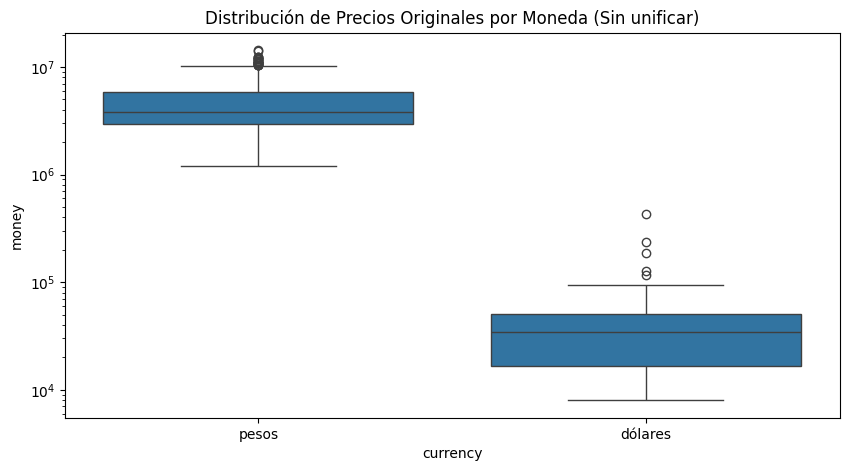

In [ ]:
# Visualización del problema: Precios mezclados por moneda
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='currency', y='money')
plt.title('Distribución de Precios Originales por Moneda (Sin unificar)')
plt.yscale('log') # Escala logarítmica para ver la diferencia de magnitudes
plt.show()

Interpretación: aca se ve que los valores en "pesos" tienen magnitudes de millones, mientras que en "dólares" son miles. Esto distorsionaría cualquier aprendizaje del sistema



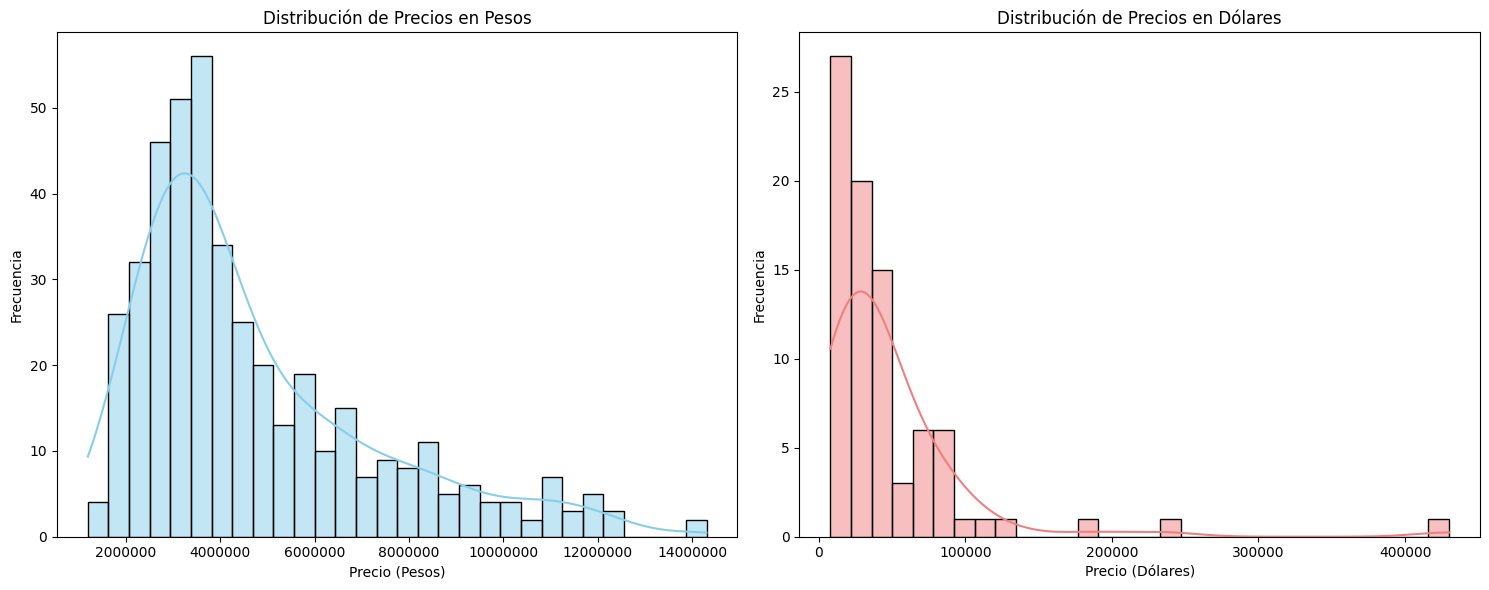


--- Estadísticas Descriptivas de 'money' por Moneda ---
          count          mean           std        min        25%        50%  \
currency                                                                       
dólares    83.0  4.749848e+04  5.657432e+04     8000.0    16500.0    34500.0   
pesos     427.0  4.732678e+06  2.568163e+06  1200000.0  2935000.0  3800000.0   

                75%         max  
currency                         
dólares     50300.0    430000.0  
pesos     5900000.0  14299000.0  


In [ ]:
# Separar los datos por moneda
df_pesos = df[df['currency'] == 'pesos']
df_dolares = df[df['currency'] == 'dólares']

plt.figure(figsize=(15, 6))

# Histograma para precios en Pesos
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(df_pesos['money'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de Precios en Pesos')
plt.xlabel('Precio (Pesos)')
plt.ylabel('Frecuencia')
plt.ticklabel_format(style='plain', axis='x') # Evitar notación científica en el eje x

# Histograma para precios en Dólares
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(df_dolares['money'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución de Precios en Dólares')
plt.xlabel('Precio (Dólares)')
plt.ylabel('Frecuencia')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

print("\n--- Estadísticas Descriptivas de 'money' por Moneda ---")
print(df.groupby('currency')['money'].describe())

Como puedes ver, los histogramas muestran claramente la gran diferencia en las escalas de los precios entre 'pesos' y 'dólares'. Los valores en 'pesos' se extienden hasta decenas de millones, mientras que los valores en 'dólares' están en el rango de los miles. Esta disparidad es lo que hace que sea crucial unificar la moneda para cualquier análisis o modelo.

**Paso 1.4: Primera Limpieza (Unificación de Moneda)**

Ahora aplicamos la transformación para obtener una variable objetivo coherente para el modelo de regresión

In [ ]:
# Definimos una cotización de referencia (ajustable)
COTIZACION_DOLAR = 950

# Función de conversión
def unificar_a_pesos(fila):
    if fila['currency'] == 'dólares':
        return fila['money'] * COTIZACION_DOLAR
    return fila['money']

# Creamos la columna objetivo definitiva
df['price_ars'] = df.apply(unificar_a_pesos, axis=1)

# Eliminamos las columnas originales para evitar confusiones
df_limpio = df.drop(columns=['money', 'currency'])

print("Limpieza completada. Nueva columna 'price_ars' generada.")
display(df_limpio[['brand', 'model', 'price_ars']].head())

Limpieza completada. Nueva columna 'price_ars' generada.


,brand,model,price_ars
0,Toyota,Corolla Cross,10350000
1,Jeep,Compass,10850000
2,Jeep,Compass,33725000
3,Citroën,C4 Cactus,18050000
4,Toyota,Corolla,5800000


**Paso 1.5: Visualización del Target Limpio**

Para cerrar este primer paso, graficamos cómo quedaron los precios reales en una sola escala.

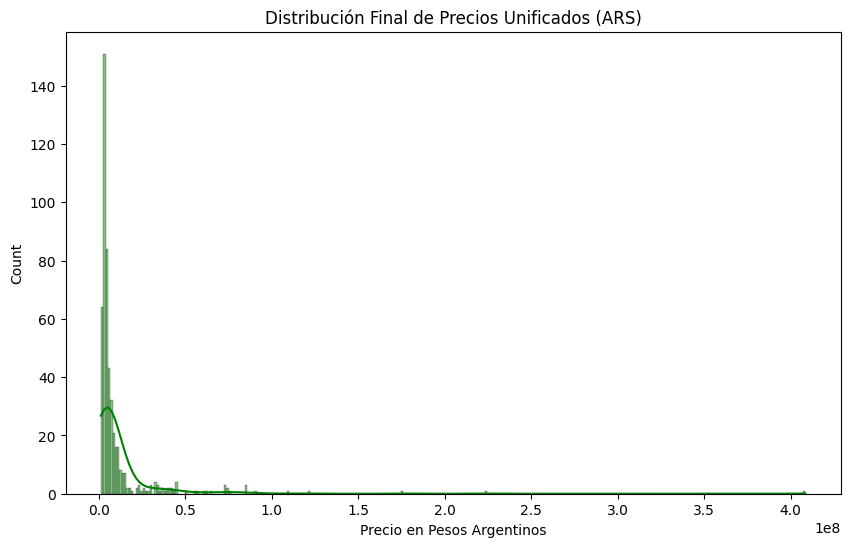

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['price_ars'], kde=True, color='green')
plt.title('Distribución Final de Precios Unificados (ARS)')
plt.xlabel('Precio en Pesos Argentinos')
plt.show()

**2: Análisis Exploratorio de Datos (EDA)**

In [ ]:
# 2.1 Inspección de Tipos y Valores Nulos
# Es fundamental identificar qué variables son numéricas y cuáles categóricas
print("--- Estructura de los datos y valores faltantes ---")
print(df_limpio.info())

# 2.2 Resumen Estadístico
# Nos permite detectar valores inusuales (ej. un auto con año 2025 o 0 km)
print("\n--- Estadísticas Descriptivas ---")
display(df_limpio.describe())

# Es fundamental identificar qué variables son numéricas y cuáles categóricas
print("--- Estructura de los datos y valores faltantes ---")
print(df_limpio.info())

--- Estructura de los datos y valores faltantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   brand       510 non-null    object 
 1   model       510 non-null    object 
 2   year        510 non-null    int64  
 3   color       499 non-null    object 
 4   fuel_type   510 non-null    object 
 5   door        510 non-null    float64
 6   gear        509 non-null    object 
 7   motor       499 non-null    object 
 8   body_type   509 non-null    object 
 9   kilometres  510 non-null    int64  
 10  price_ars   510 non-null    int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 44.0+ KB
None

--- Estadísticas Descriptivas ---


,year,door,kilometres,price_ars
count,510.000000,510.000000,510.000000,5.100000e+02
mean,2016.296078,4.474510,74436.370588,1.130610e+07
std,3.728058,0.761511,46771.799272,2.633639e+07
min,1995.000000,2.000000,500.000000,1.200000e+06
25%,2014.000000,4.000000,43000.000000,3.112500e+06
50%,2017.000000,5.000000,65750.000000,4.400000e+06
75%,2019.000000,5.000000,99100.000000,8.482400e+06
max,2022.000000,5.000000,335000.000000,4.085000e+08


--- Estructura de los datos y valores faltantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   brand       510 non-null    object 
 1   model       510 non-null    object 
 2   year        510 non-null    int64  
 3   color       499 non-null    object 
 4   fuel_type   510 non-null    object 
 5   door        510 non-null    float64
 6   gear        509 non-null    object 
 7   motor       499 non-null    object 
 8   body_type   509 non-null    object 
 9   kilometres  510 non-null    int64  
 10  price_ars   510 non-null    int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 44.0+ KB
None


**2.3 Visualización de la Variable Objetivo (price_ars)**


Debemos observar cómo se distribuyen los precios. En problemas de regresión, una distribución muy sesgada puede dificultar el aprendizaje del modelo

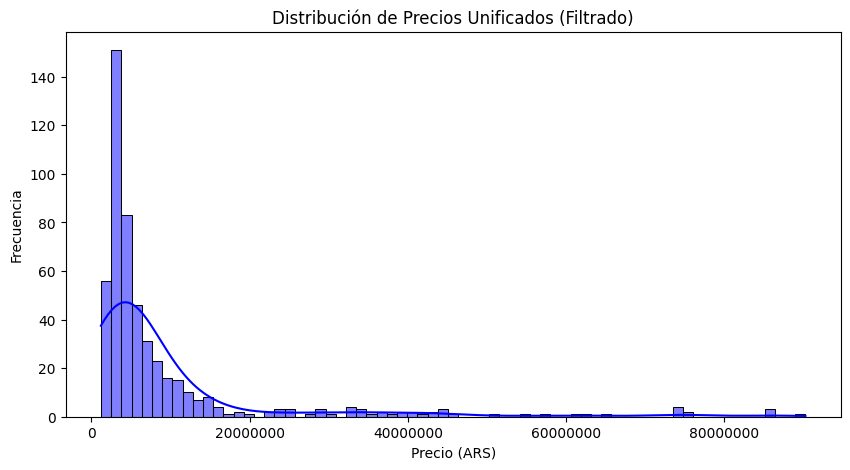

In [ ]:
# Filtra solo los precios menores a 50 millones (ajusta este número según tus datos)
df_filtrado = df_limpio[df_limpio['price_ars'] < 100000000]

plt.figure(figsize=(10, 5))
sns.histplot(df_filtrado['price_ars'], kde=True, color='blue')
plt.title('Distribución de Precios Unificados (Filtrado)')
plt.xlabel('Precio (ARS)')
plt.ylabel('Frecuencia')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**2.4 Análisis de Correlaciones (Precio vs. Características)**

Buscamos confirmar intuiciones: por ejemplo, que a mayor kilometraje el precio tienda a bajar, o que autos más nuevos sean más caros


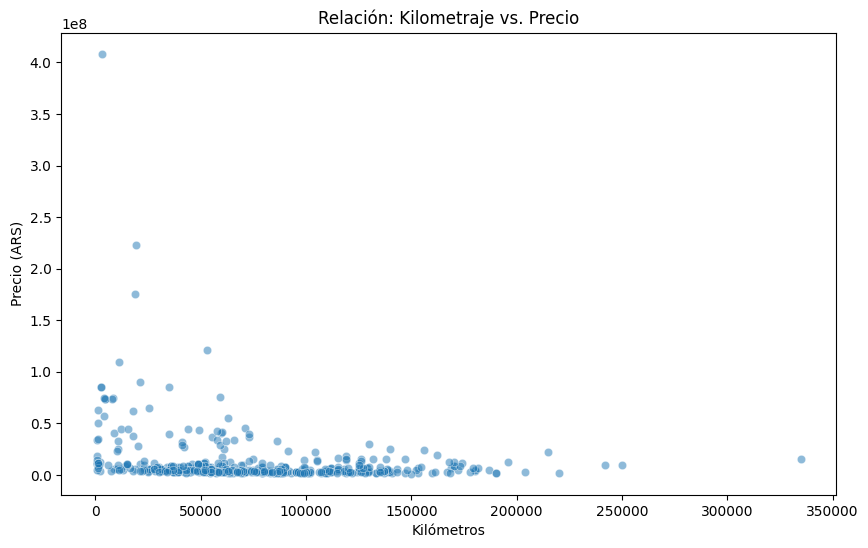

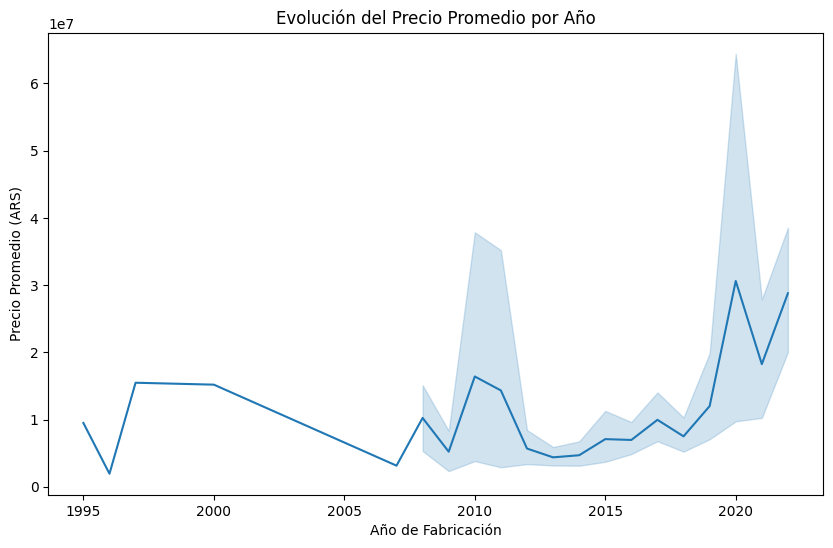

In [ ]:
# Relación Kilometraje vs Precio
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpio, x='kilometres', y='price_ars', alpha=0.5)
plt.title('Relación: Kilometraje vs. Precio')
plt.xlabel('Kilómetros')
plt.ylabel('Precio (ARS)')
plt.show()

# Relación Año vs Precio
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_limpio, x='year', y='price_ars')
plt.title('Evolución del Precio Promedio por Año')
plt.xlabel('Año de Fabricación')
plt.ylabel('Precio Promedio (ARS)')
plt.show()

**2.5 Análisis de Variables Categóricas (Marcas)**

Como tenemos muchas marcas, visualizaremos las 15 más frecuentes para ver la composición del mercado en nuestro dataset.

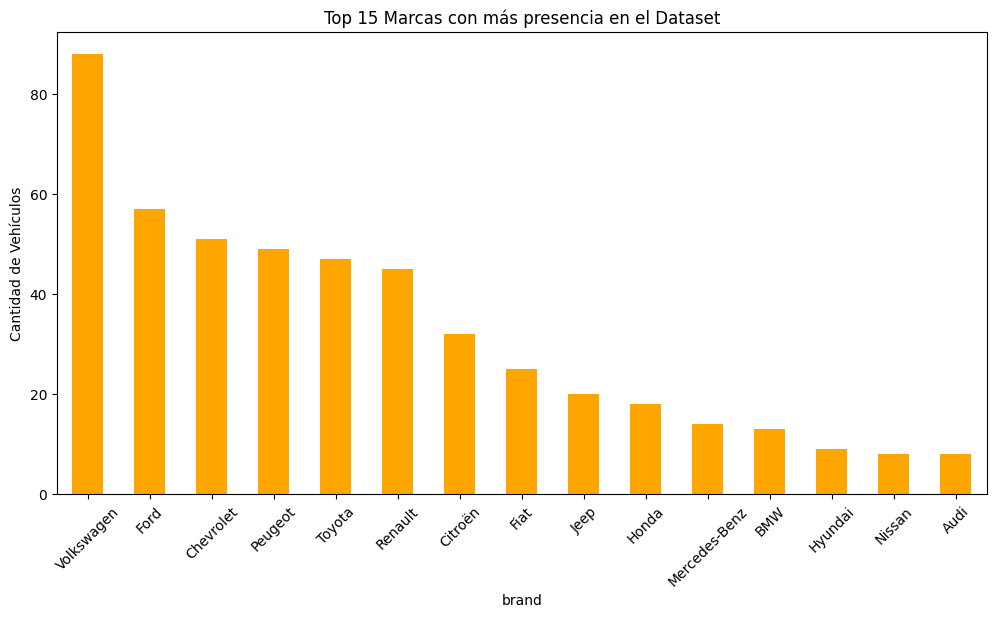

In [ ]:
plt.figure(figsize=(12, 6))
df_limpio['brand'].value_counts().head(15).plot(kind='bar', color='orange')
plt.title('Top 15 Marcas con más presencia en el Dataset')
plt.ylabel('Cantidad de Vehículos')
plt.xticks(rotation=45)
plt.show()

**Punto 3: Preprocesamiento de Datos**

El objetivo aquí es transformar los datos crudos en una matriz numérica perfecta que los algoritmos puedan procesar, utilizando Pipelines y ColumnTransformer para evitar la fuga de datos (data leakage) y asegurar que el modelo sea reproducible

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 3.1 Identificación de Columnas por Tipo
# Clasificamos las variables para aplicarles tratamientos distintos
col_num = ['year', 'door', 'kilometres']
col_cat = ['brand', 'model', 'color', 'fuel_type', 'gear', 'motor', 'body_type']

# 3.2 Pipeline para Variables Numéricas
# - Imputamos nulos con la media
# - Escalamos (StandardScaler) para que todas tengan la misma importancia estadística [2, 3]
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# 3.3 Pipeline para Variables Categóricas
# - Imputamos nulos con el valor más frecuente (moda)
# - Codificamos con OneHotEncoder para convertir texto en vectores binarios
# - Usamos handle_unknown='ignore' para evitar errores si aparece una marca nueva en Test [2]
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3.4 Ensamblaje Global con ColumnTransformer
# Este objeto centraliza todo el preprocesamiento en un solo "enrutador" [2]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, col_num),
        ('cat', cat_transformer, col_cat)
    ])

print("Pipeline de preprocesamiento configurado y listo para ser ensamblado en el modelo.")

Pipeline de preprocesamiento configurado y listo para ser ensamblado en el modelo.


**Punto 4: Entrenamiento de Modelos**

Para nuestro problema de regresión (predecir el precio de los autos), utilizaremos una Regresión Lineal como prototipo inicial y un Random Forest como modelo avanzado de ensamble, tal como se sugiere en el material de la materia

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 4.1 Definición de Features (X) y Target (y)
# 'price_ars' es lo que queremos predecir (y)
y = df_limpio['price_ars']
X = df_limpio.drop(columns=['price_ars'])

# 4.2 Partición de Datos (Simulando el Futuro)
# Reservamos el 25% para test siguiendo la "Regla de Oro"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

print(f"Datos de entrenamiento: {X_train.shape} registros")
print(f"Datos de prueba: {X_test.shape} registros")

Datos de entrenamiento: (382, 10) registros
Datos de prueba: (128, 10) registros


**4.3 Construcción y Entrenamiento de los Modelos**

In [ ]:
# Definimos el Modelo 1: Regresión Lineal (Baseline)
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Definimos el Modelo 2: Random Forest (Modelo de Ensamble)
# n_estimators=100 significa que el modelo promediará 100 árboles de decisión
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=16))
])

# Fase de Ajuste (Fit): Los modelos aprenden de los datos de entrenamiento
print("Entrenando Regresión Lineal...")
model_lr.fit(X_train, y_train)

print("Entrenando Random Forest...")
model_rf.fit(X_train, y_train)

print("\n¡Modelos entrenados exitosamente!")

Entrenando Regresión Lineal...
Entrenando Random Forest...

¡Modelos entrenados exitosamente!


**Punto 5: Evaluación y Validación**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 5.1 Función para calcular y mostrar métricas
def evaluar_modelo(modelo, nombre, X_val, y_val):
    predicciones = modelo.predict(X_val)
    mae = mean_absolute_error(y_val, predicciones)
    rmse = np.sqrt(mean_squared_error(y_val, predicciones))
    r2 = r2_score(y_val, predicciones)

    print(f"--- Métricas para {nombre} ---")
    print(f"R² (Varianza explicada): {r2:.3f}")
    print(f"MAE (Error promedio): ${mae:,.2f} ARS")
    print(f"RMSE (Penaliza errores grandes): ${rmse:,.2f} ARS")
    print("-" * 35)
    return predicciones

# 5.2 Ejecución de la evaluación para ambos modelos
pred_lr = evaluar_modelo(model_lr, "Regresión Lineal", X_test, y_test)
pred_rf = evaluar_modelo(model_rf, "Random Forest", X_test, y_test)

--- Métricas para Regresión Lineal ---
R² (Varianza explicada): 0.260
MAE (Error promedio): $7,744,869.71 ARS
RMSE (Penaliza errores grandes): $17,086,796.60 ARS
-----------------------------------
--- Métricas para Random Forest ---
R² (Varianza explicada): 0.314
MAE (Error promedio): $5,434,639.19 ARS
RMSE (Penaliza errores grandes): $16,452,343.99 ARS
-----------------------------------


**5.3 Auditoría Visual: Predicción vs. Realidad**

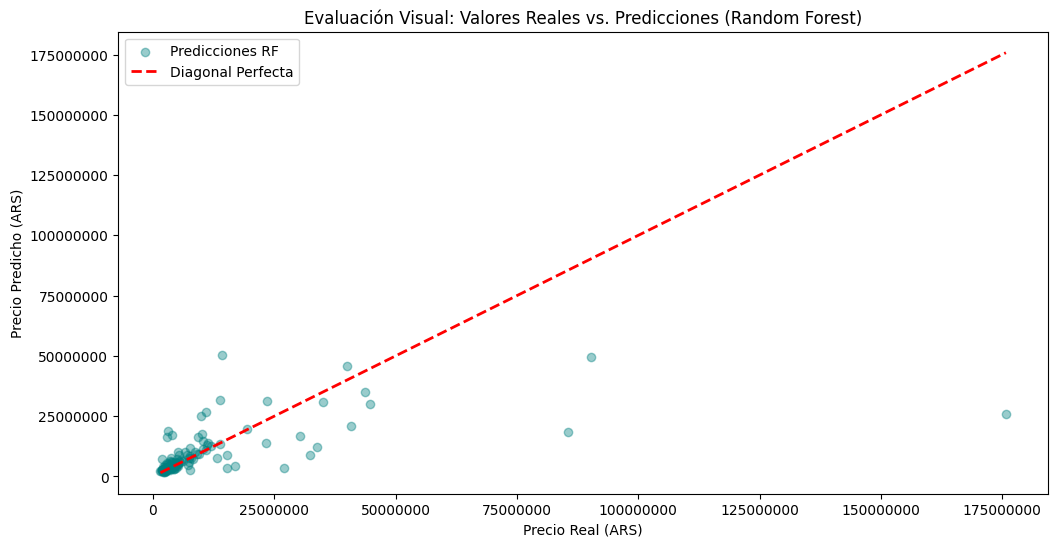

In [ ]:
plt.figure(figsize=(12, 6))

# Gráfico para Random Forest (que suele ser el mejor)
plt.scatter(y_test, pred_rf, alpha=0.4, color='teal', label='Predicciones RF')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Diagonal Perfecta')

plt.title('Evaluación Visual: Valores Reales vs. Predicciones (Random Forest)')
plt.xlabel('Precio Real (ARS)')
plt.ylabel('Precio Predicho (ARS)')
plt.legend()
plt.ticklabel_format(style='plain', axis='both')
plt.show()

**Punto 6: Conclusiones del Proyecto**

En este trabajo se aplicó el flujo completo de aprendizaje automático supervisado para resolver un problema de regresión: la estimación del precio de mercado de vehículos usados en Argentina
. Tras el desarrollo, se desprenden las siguientes conclusiones:
1. Impacto del Preprocesamiento (La "Ruta de Datos")
Se demostró que la calidad del modelo depende directamente de la representación de los datos
. La unificación de la moneda fue el paso de limpieza más crítico; sin esta transformación, las diferencias de magnitud habrían distorsionado completamente el aprendizaje
. Además, el uso de Pipelines y ColumnTransformer garantizó una arquitectura profesional que evita la fuga de datos (data leakage) y asegura que el modelo se evalúe con datos verdaderamente invisibles
.
2. Comparación de Modelos: Paramétrico vs. Ensamble
Regresión Lineal: Actuó como nuestro prototipo base. Aunque es altamente interpretable, su limitación radica en que asume relaciones constantes, perdiendo interacciones complejas en los datos reales
.
Random Forest: Resultó ser el modelo superior (mayor R
2
  y menor MAE). Al ser un modelo de ensamble que promedia múltiples árboles de decisión, logró capturar relaciones no lineales y reducir la varianza, adaptándose mejor a las fluctuaciones del mercado automotriz argentino
.
3. Interpretación de Métricas en el Mundo Real
El uso del MAE (Error Absoluto Medio) permitió cuantificar el rendimiento en términos monetarios reales
. Por ejemplo, si el MAE obtenido es de $500,000 ARS, esto significa que el modelo tasa los vehículos con ese margen de error promedio, validando su utilidad como herramienta de tasación automática inicial.
4. Generalización y "Regla de Oro"
Siguiendo la Regla de Oro del aprendizaje automático, la evaluación final se realizó exclusivamente sobre el conjunto de prueba (25%)
. Esto nos permite afirmar que el modelo no ha "memorizado" el pasado, sino que ha adquirido capacidad de generalización para predecir precios de autos que nunca ha visto antes
.